# Reionisation observables from the electron power spectrum

In [1]:
import time
import matplotlib.pyplot as plt
from matplotlib import rc, colors
import numpy as np
from astropy import cosmology, units, constants
# import healpy as hp
import os
from scipy.interpolate import interp1d
from tqdm import tqdm

In [2]:
from theory import Pee_model
from utils import *

In [3]:
rc("font", **{"family": "serif", "serif": ["times new roman"], "size": 18})
# rc("text", usetex=True)
rc("axes", linewidth=1.5)

In [4]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [5]:
CL = 68
percentile1 = (100.-CL)/2.
percentile2 = CL+(100.-CL)/2.

In [6]:
ells = np.arange(50, 10000, step=250)

In [7]:
cos = cosmology.Planck18

## Consistent reionisation observables: power spectra

The `Pee_model` class allows you to compute the kSZ angular power spectrum, the optical depth power spectrum, and the 21cm power spectrum, all following a consistent reionsation model, based on the electron power spectrum parameterisation introduced in Gorce et. al 2020.

In [8]:
model = Pee_model(
    h=cos.h,
    Ob_0=cos.Ob0,
    Om_0=cos.Om0,
    verbose=True, run_camb=True)

zre_h = 7.0, zend = 5.5
Late-time ionisation fraction: 1.16
tau = 0.0534
Running CAMB...


Text(0.5, 1.0, '$z=7.0$')

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: times new roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: times new roman


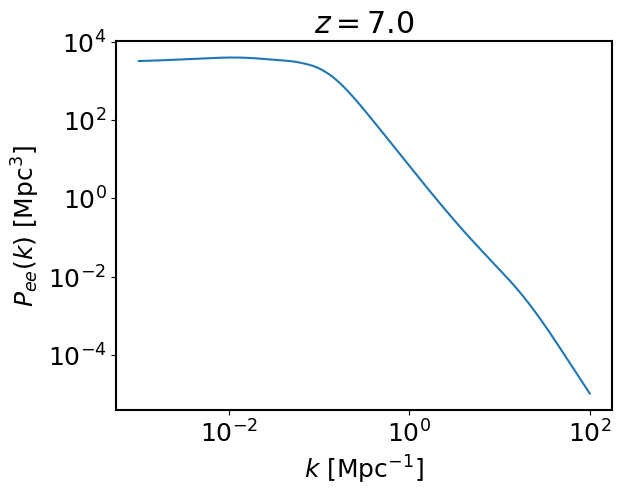

In [9]:
klog = np.logspace(-3, 2, 500)

plt.figure()
plt.loglog(klog, model.Pee(klog, model.zre_h))
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{ee}(k)$ [Mpc$^3$]')
plt.title(rf'$z={model.zre_h:.1f}$')

### Reionisation history

5.5 7.0


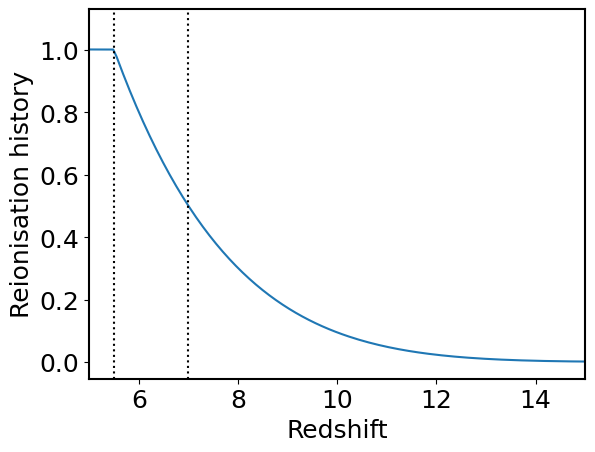

In [10]:
z = np.linspace(0, 20, 300)
print(model.zend_h, model.zre_h)
plt.figure()
plt.plot(z, model.xe(z)/1.08)
plt.xlabel(r'Redshift')
plt.ylabel(r'Reionisation history')
plt.xlim(5, 15)
plt.axvline(model.zend_h, color='k', ls=':')
plt.axvline(model.zre_h, color='k', ls=':')

### $\tau$ power spectrum

To compute the $\tau-\tau$ power spectrum, use the `get_tau` method. 
The following will output the tau power on a range of multipoles `ells` as $\mathcal{D}_\ell = T_\mathrm{CMB} \ell (\ell + 1) C_\ell / 2 \pi$.

Computation took 0.2 seconds.


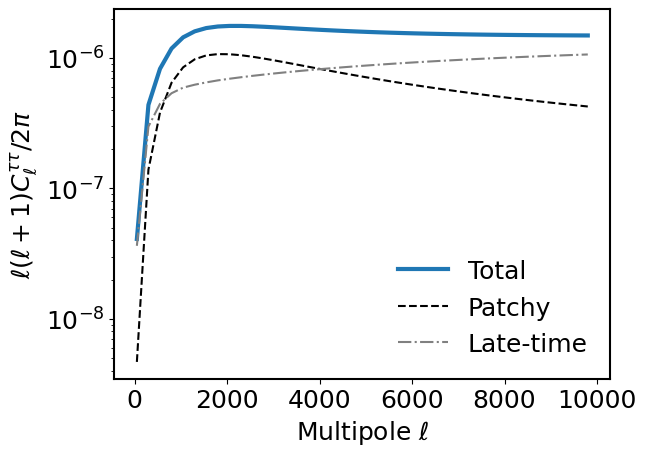

In [11]:
t0 = time.time()
tau_ps = model.get_tau(ells=ells, signal='both', Dells=True)
t1 = time.time()
print(f'Computation took {t1-t0:.1f} seconds.')

plt.figure()
plt.semilogy(ells, np.sum(tau_ps, axis=1), label='Total', lw=3.)
plt.plot(ells, tau_ps[:, 0], label='Patchy', ls='--', color='k')
plt.plot(ells, tau_ps[:, 1], label='Late-time', ls='-.', color='grey')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
# plt.ylim(1e-5, 1e-2)
plt.legend(frameon=False)
# plt.xlim(0, 3000)

### 21cm power spectrum

To compute the 21cm power spectrum, use the `get_p21(k,z)` method.

In [12]:
zarr = np.linspace(5., 10, 20)
karr = np.logspace(-4, 2, 100)

ps_21 = model.get_p21(karr, zarr[:, None], mK=True, log=False, pk_units=True)

Text(0, 0.5, 'Reionisation history')

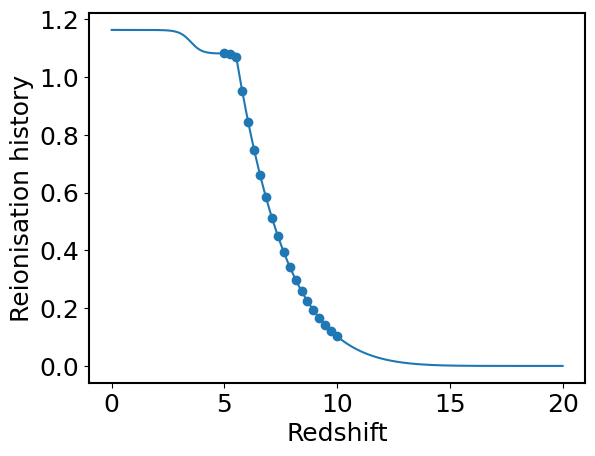

In [13]:
z = np.linspace(0, 20, 300)

plt.figure()
plt.plot(z, model.xe(z))
plt.scatter(zarr, model.xe(zarr))
plt.xlabel(r'Redshift')
plt.ylabel(r'Reionisation history')

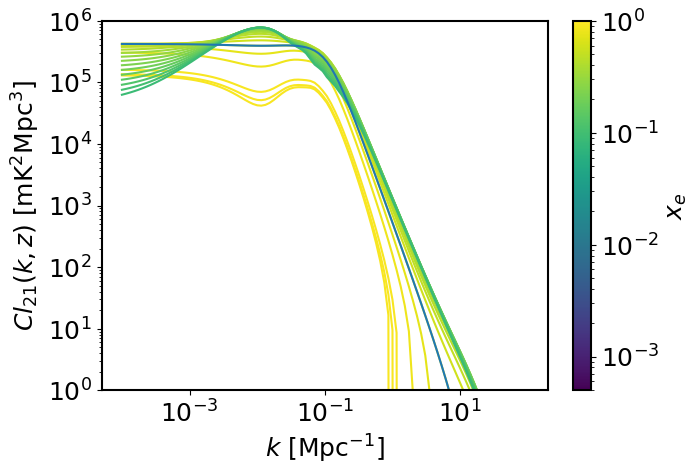

In [14]:
cmap = colormaps['viridis']
norm = colors.LogNorm(vmin=5e-4, vmax=1.)

fig, ax = plt.subplots()
for iz, z in enumerate(zarr):
    ax.loglog(karr, ps_21[iz], color=cmap(norm(model.xe(z)[0]/model.f)))
ax.plot(karr, ps_21[5])
ax.set_ylim(1e0, 1e6)
ax.set_xlabel(r'$k$ [Mpc$^{-1}]$')
ax.set_ylabel(r'$Cl_{21}(k, z)$ [mK$^2$Mpc$^3]$')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, label=r'$x_e$', ax=ax)

## Analytical cross-spectrum

In [15]:
Dl_tau_21 = model.get_tau_21_cross(model.zre_h, ells, Dells=True, delta_nu=0.)
print(Dl_tau_21.unit)

uK


In [16]:
cl21 = model.get_cl21(model.zre_h, ells, Dells=True, delta_nu=0.)
print(cl21.unit)

uK2


Text(0.5, 1.0, '$z=7.0$')

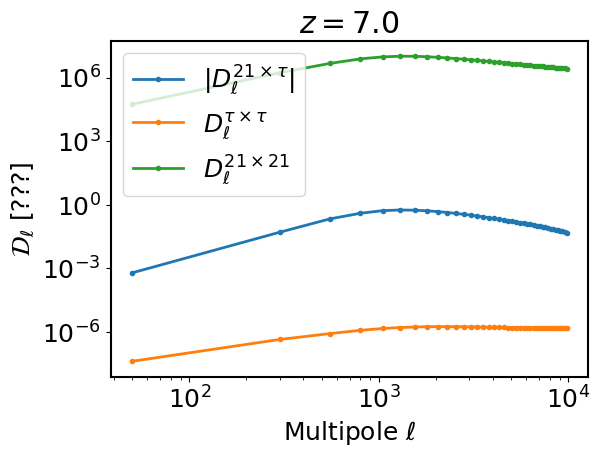

In [17]:
fig, ax = plt.subplots()
ax.plot(ells, np.abs(Dl_tau_21.to(units.uK)), marker='.', label=r'$\vert D_\ell^{21\times \tau}\vert$', lw=2)
ax.plot(ells, tau_ps.sum(1), marker='.', label=r'$D_\ell^{\tau\times \tau}$', lw=2)
ax.plot(ells, cl21.to(units.uK**2), marker='.', label=r'$D_\ell^{21\times 21}$', lw=2)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$ [???]')
plt.tight_layout()
ax.legend()
# ax.legend(frameon=False, ncols=2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title(rf'$z={model.zre_h:.1f}$')

Text(0.5, 1.0, '$z=7.0$')

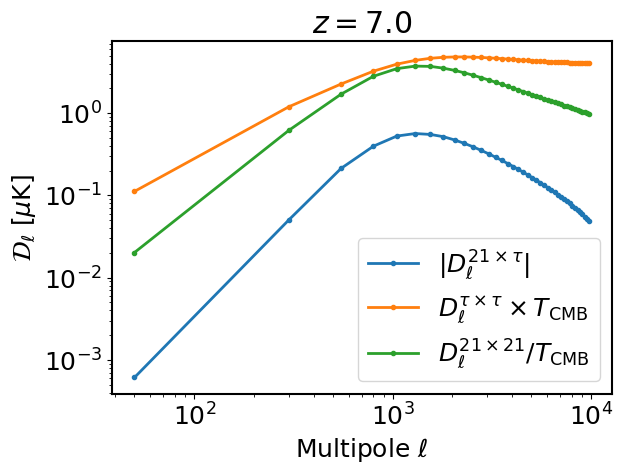

In [18]:
fig, ax = plt.subplots()
ax.plot(ells, np.abs(Dl_tau_21.to(units.uK)), marker='.', label=r'$\vert D_\ell^{21\times \tau}\vert$', lw=2)
ax.plot(ells, tau_ps.sum(1)*(model.T_cmb*1e6), marker='.', label=r'$D_\ell^{\tau\times \tau} \times T_\mathrm{CMB}$', lw=2)
ax.plot(ells, cl21.to(units.uK**2)/(model.T_cmb*1e6), marker='.', label=r'$D_\ell^{21\times 21} / T_\mathrm{CMB}$', lw=2)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell$ [$\mu$K]')
plt.tight_layout()
ax.legend()
# ax.legend(frameon=False, ncols=2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title(rf'$z={model.zre_h:.1f}$')

Text(0.5, 1.0, '$z=7.0$')

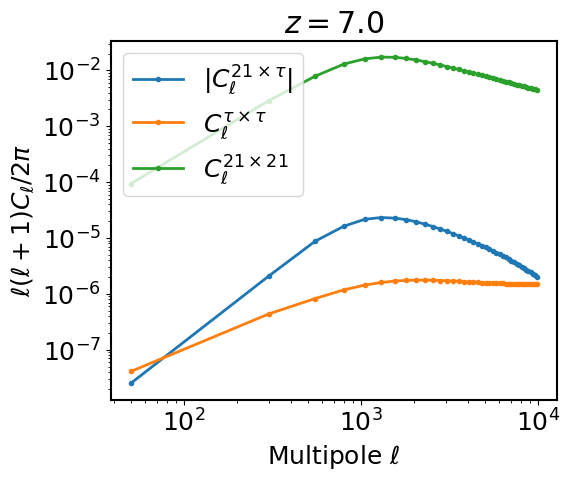

In [19]:
fig, ax = plt.subplots()
ax.plot(ells, np.abs(Dl_tau_21.to(units.uK))/model.T0(model.zre_h), marker='.', label=r'$\vert C_\ell^{21\times \tau}\vert$', lw=2)
ax.plot(ells, tau_ps.sum(1), marker='.', label=r'$C_\ell^{\tau\times \tau}$', lw=2)
ax.plot(ells, cl21.to(units.uK**2)/model.T0(model.zre_h)**2, marker='.', label=r'$C_\ell^{21\times 21}$', lw=2)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell (\ell+1)C_\ell/2 \pi$ ')
plt.tight_layout()
ax.legend()
# ax.legend(frameon=False, ncols=2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title(rf'$z={model.zre_h:.1f}$')

20it [00:03,  5.29it/s]


Text(0.5, 1.0, '$\\Delta \\nu=0.0$MHz')

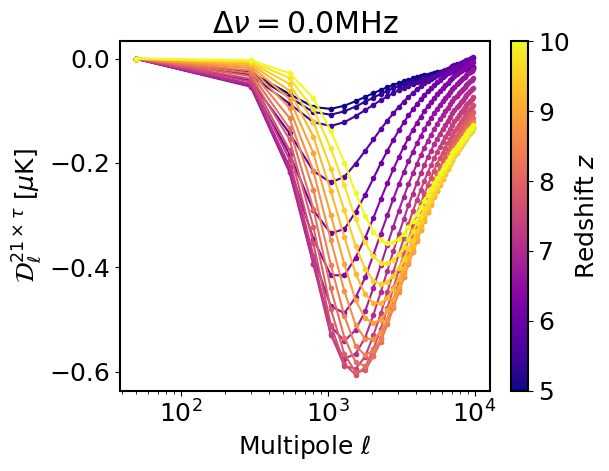

In [39]:
cmap = colormaps['plasma']
norm = colors.Normalize(vmin=np.min(zarr), vmax=np.max(zarr)) #can also use LogNorm
dnu = 0.

fig, ax = plt.subplots()
for iz, z in tqdm(enumerate(zarr)):
    Dl_tau_21 = model.get_tau_21_cross(z, ells, Dells=True, delta_nu=dnu).to(units.uK)
    ax.errorbar(
        ells, Dl_tau_21,
        marker='.', label=rf'$z_{{21}}={z:.1f}$', color=cmap(norm(z)))
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{21\times \tau}$ [$\mu$K]')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, ax=ax, label=r'Redshift $z$')
plt.tight_layout()
# ax.legend(frameon=False, ncols=2)
ax.set_xscale('log')
ax.set_title(rf'$\Delta \nu={dnu:.1f}$MHz')

20it [00:02,  7.48it/s]


Text(0.5, 1.0, '$\\Delta \\nu=10.0$MHz')

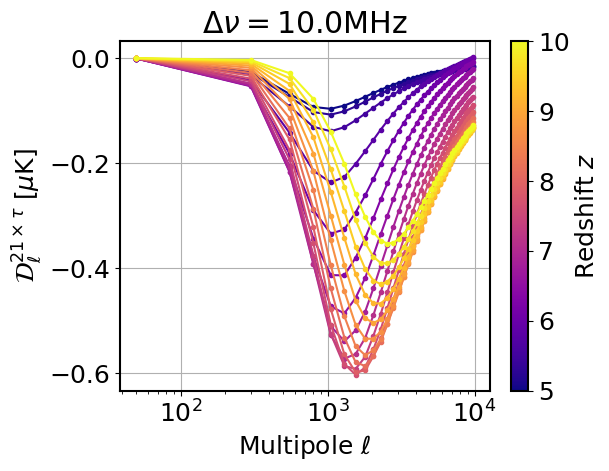

In [43]:
cmap = colormaps['plasma']
norm = colors.Normalize(vmin=np.min(zarr), vmax=np.max(zarr)) #can also use LogNorm
dnu = 10.  # MHz

fig, ax = plt.subplots()
for iz, z in tqdm(enumerate(zarr)):
    Dl_tau_21 = model.get_tau_21_cross(z, ells, Dells=True, delta_nu=dnu).to(units.uK)
    ax.errorbar(
        ells, Dl_tau_21,
        marker='.', label=rf'$z_{{21}}={z:.1f}$', color=cmap(norm(z)))
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{21\times \tau}$ [$\mu$K]')
plt.grid()
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, ax=ax, label=r'Redshift $z$')
plt.tight_layout()
# ax.legend(frameon=False, ncols=2)
ax.set_xscale('log')
ax.set_title(rf'$\Delta \nu={dnu:.1f}$MHz')

6it [00:00,  7.31it/s]


Text(0.5, 1.0, '$\\Delta \\nu=0.1$MHz')

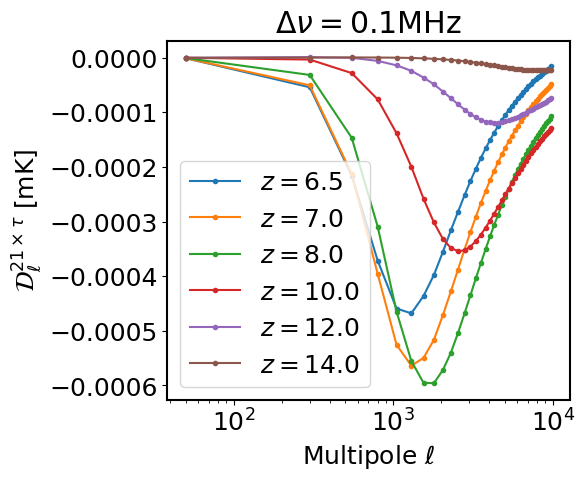

In [37]:
dnu = 0.1

fig, ax = plt.subplots()
for iz, z in tqdm(enumerate([6.5, 7., 8., 10, 12, 14])):
    Dl_tau_21 = model.get_tau_21_cross(z, ells, Dells=True, delta_nu=dnu).to(units.mK)
    ax.errorbar(
        ells, Dl_tau_21,
        marker='.', label=rf'$z={z:.1f}$')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{21\times \tau}$ [mK]')
plt.legend()
plt.tight_layout()
# ax.legend(frameon=False, ncols=2)
ax.set_xscale('log')
ax.set_title(rf'$\Delta \nu={dnu:.1f}$MHz')

9it [00:05,  1.67it/s]


Text(0.5, 1.0, '$z=7.0$')

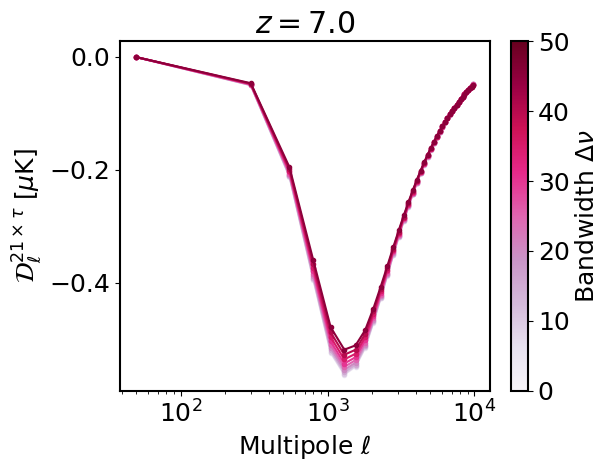

In [42]:
cmap = colormaps['PuRd']
norm = colors.Normalize(vmin=0, vmax=50) #can also use LogNorm
z = model.zre_h
fig, ax = plt.subplots()
for i, dnu in tqdm(enumerate(np.arange(5, 50, step=5.))):
    Dl_tau_21 = model.get_tau_21_cross(z, ells, Dells=True, delta_nu=dnu, nz=500).to(units.uK)
    ax.errorbar(
        ells, Dl_tau_21,
        marker='.', label=rf'$\Delta\nu={dnu:.1f}MHz$', color=cmap(norm(dnu)))
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{21\times \tau}$ [$\mu$K]')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, ax=ax, label=r'Bandwidth $\Delta\nu$')
plt.tight_layout()
# ax.legend(frameon=False, ncols=2)
ax.set_xscale('log')
ax.set_title(rf'$z={model.zre_h:.1f}$')